# Spinful equal-spin p-wave SCF on a 1D chain

This example uses a spinful normal chain and self-consistently updates nearest-neighbor equal-spin p-wave bond pairings. It is not the spinless Kitaev-chain construction: the BdG pairing block carries explicit spin projectors, with `Delta_up(i)` and `Delta_down(i)` living on bonds `(i, i+1)`.


In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS

include("../src/TensorBinding.jl")
using .TensorBinding


## 1. Spinful normal chain

We start from the package's usual spinless chain builder and add a spin degree of freedom. The bond pairing profiles still live on the physical position-qubit sites.


In [2]:
L = 3
N = 2^L
t = 1.0
mu = 0.0

H_seed = TensorBinding.get_Hamiltonian("chain_1d", t; L=L, scale=4.0)
pos_sites = H_seed.sites

H0 = deepcopy(H_seed)
TensorBinding.add_spin!(H0)

println(H0)


TBHamiltonian | L=3, N=8 +spin, scale=auto, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


## 2. Helical p-wave seed

For an open chain, only bonds `0:(N-2)` are physical for nearest-neighbor pairing. The final profile entry is kept zero so plots show the unused edge value explicitly.


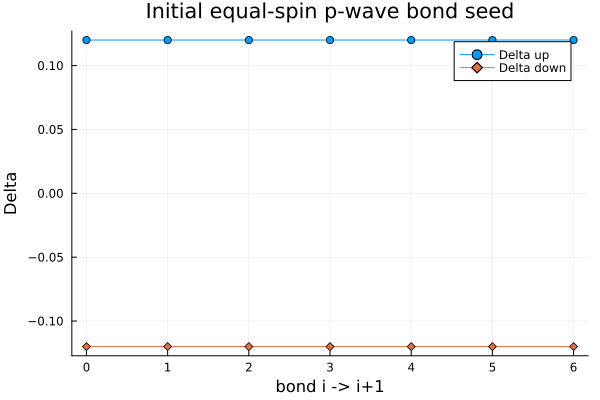

In [3]:
Delta0 = 0.12
bond_seed(n) = n <= N - 2 ? Delta0 : 0.0

Delta_up0 = TensorBinding.scf_profile_mps(
    L,
    pos_sites,
    bond_seed;
    type=ComplexF64,
    tol=1e-10,
)
Delta_dn0 = TensorBinding.scf_profile_mps(
    L,
    pos_sites,
    n -> -bond_seed(n);
    type=ComplexF64,
    tol=1e-10,
)

bond_sites = 0:N-2
Delta_up_vals = [TensorBinding.scf_eval_profile_mps(Delta_up0, n) for n in bond_sites]
Delta_dn_vals = [TensorBinding.scf_eval_profile_mps(Delta_dn0, n) for n in bond_sites]

plot(bond_sites, real.(Delta_up_vals);
     marker=:circle,
     xlabel="bond i -> i+1",
     ylabel="Delta",
     title="Initial equal-spin p-wave bond seed",
     label="Delta up")
plot!(bond_sites, real.(Delta_dn_vals); marker=:diamond, label="Delta down")


## 3. Equal-spin p-wave SCF

`eta_down=-1` only sets the initial helical seed. The self-consistent update applies the same gap equation in both equal-spin channels, and the relative sign is then preserved or changed by the BdG solution itself. The anomalous bond profile is extracted from the Nambu off-diagonal block using the non-cyclic shift MPO.


In [6]:
V = 3.2

result = TensorBinding.scf_pwave_equalspin(
    H0,
    V;
    initial_up=Delta_up0,
    initial_dn=Delta_dn0,
    eta_down=-1.0,
    distance=1,
    pairing_sign=-1.0,
    mu=mu,
    density_method=:mcweeny,
    scale=6,
    max_scf_iter=65,
    purif_maxiter=30,
    purif_tol=1e-5,
    scf_tol=1e-3,
    mix=0.75,
    maxdim=100,
    cutoff=1e-8,
    verbose=true,
)

println("converged = ", result.converged)
println("iterations = ", result.iterations)
println("final RMS = ", result.rms_error)


p-wave equal-spin SCF iter=1 rms=0.0467305516104598
p-wave equal-spin SCF iter=2 rms=0.05262815497946324
p-wave equal-spin SCF iter=3 rms=0.06453218855318356
p-wave equal-spin SCF iter=4 rms=0.07637524018401781
p-wave equal-spin SCF iter=5 rms=0.08521942423785936
p-wave equal-spin SCF iter=6 rms=0.08775653971277123
p-wave equal-spin SCF iter=7 rms=0.08183875916937242
p-wave equal-spin SCF iter=8 rms=0.06863868377232696
p-wave equal-spin SCF iter=9 rms=0.052761872513839465
p-wave equal-spin SCF iter=10 rms=0.03716468418943176
p-wave equal-spin SCF iter=11 rms=0.02561650879746234
p-wave equal-spin SCF iter=12 rms=0.017975005619144075
p-wave equal-spin SCF iter=13 rms=0.01160909913896278
p-wave equal-spin SCF iter=14 rms=0.007300707095218398
p-wave equal-spin SCF iter=15 rms=0.005053979178927838
p-wave equal-spin SCF iter=16 rms=0.003298609721511039
p-wave equal-spin SCF iter=17 rms=0.002146277440768627
p-wave equal-spin SCF iter=18 rms=0.0014826893083759644
p-wave equal-spin SCF iter=19 

## 4. Bond pairing and convergence


max |Delta_up + V F_up| = 0.0002770174375331669
max |Delta_dn + V F_dn| = 0.000277017438026661


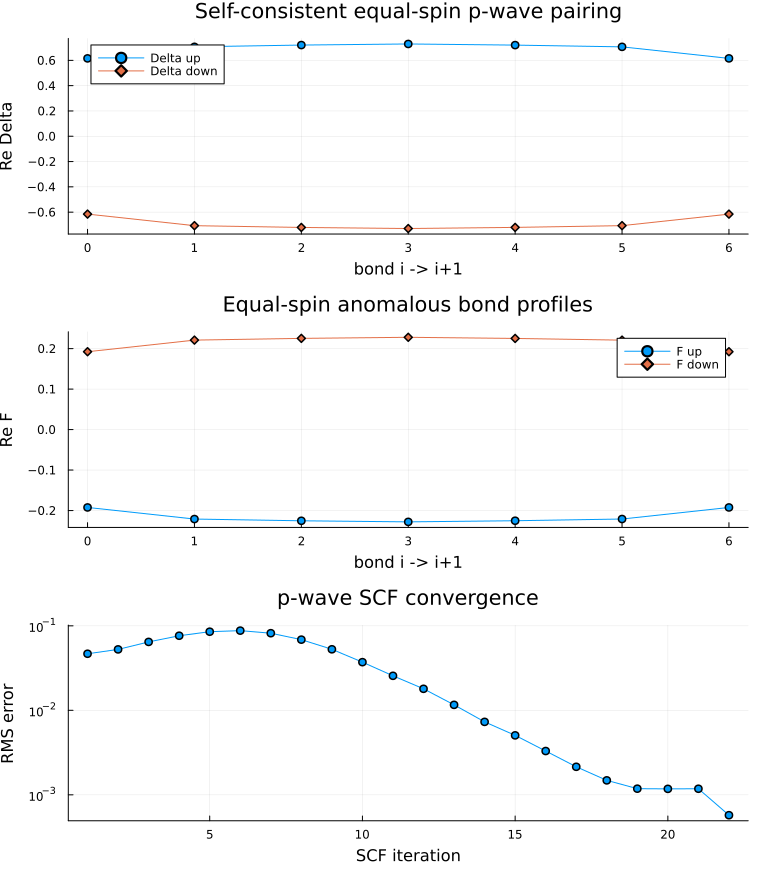

In [7]:
Delta_up = [TensorBinding.scf_eval_profile_mps(result.delta_up_mps, n) for n in bond_sites]
Delta_dn = [TensorBinding.scf_eval_profile_mps(result.delta_dn_mps, n) for n in bond_sites]
F_up = [TensorBinding.scf_eval_profile_mps(result.anomalous_up_mps, n) for n in bond_sites]
F_dn = [TensorBinding.scf_eval_profile_mps(result.anomalous_dn_mps, n) for n in bond_sites]
hist_iter = [h.iter for h in result.history]
hist_rms = [h.rms_error for h in result.history]


res_up = Delta_up .+ V .* F_up
res_dn = Delta_dn .+ V .* F_dn
println("max |Delta_up + V F_up| = ", maximum(abs.(res_up)))
println("max |Delta_dn + V F_dn| = ", maximum(abs.(res_dn)))

p1 = plot(bond_sites, real.(Delta_up);
          marker=:circle,
          xlabel="bond i -> i+1",
          ylabel="Re Delta",
          title="Self-consistent equal-spin p-wave pairing",
          label="Delta up")
plot!(p1, bond_sites, real.(Delta_dn); marker=:diamond, label="Delta down")

p2 = plot(bond_sites, real.(F_up);
          marker=:circle,
          xlabel="bond i -> i+1",
          ylabel="Re F",
          title="Equal-spin anomalous bond profiles",
          label="F up")
plot!(p2, bond_sites, real.(F_dn); marker=:diamond, label="F down")

p3 = plot(hist_iter, hist_rms;
          yscale=:log10,
          marker=:circle,
          xlabel="SCF iteration",
          ylabel="RMS error",
          title="p-wave SCF convergence",
          legend=false)

plot(p1, p2, p3; layout=(3, 1), size=(760, 880))
